# Sovereign CCA: Baseline Diffusion Model

Loads pre-built panel from `02_build_cca_dataset.ipynb`, adds CDS + risk-free rate, runs Merton model.

In [303]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [338]:
# Paths
PANEL_PATH = "data/processed/structural_model_panel.csv"  # From 02_build_cca_dataset.ipynb
CDS_PATH = "data/processed/CDS/Weekly_CDS.csv"
RF_PATH = "data/processed/Macroeconomic_variables/DGS1.csv"

# Model parameters
T = 5          # Time horizon (1 year)
LGD = 1    # Loss given default (60%)

---
## 1. Load Panel

In [339]:
panel = pd.read_csv(PANEL_PATH, parse_dates=['date'])
panel.drop(columns=['Unnamed: 0'], inplace=True)
print(f"Panel: {len(panel)} obs")
print(f"Columns: {list(panel.columns)}")
panel.head()




Panel: 61958 obs
Columns: ['date', 'debt_st', 'debt_lt', 'default_barrier', 'msci_index', 'msci_ret_weekly', 'n_obs', 'msci_vol_annual', 'country']


,date,debt_st,debt_lt,default_barrier,msci_index,msci_ret_weekly,n_obs,msci_vol_annual,country
0,2010-12-03,5.181000e+09,5.237300e+10,3.136750e+10,1034.304,0.033729,3,NaN,Argentina
1,2010-12-10,5.181000e+09,5.237300e+10,3.136750e+10,1063.641,0.027969,5,NaN,Argentina
2,2010-12-17,5.181000e+09,5.237300e+10,3.136750e+10,1021.676,-0.040254,5,NaN,Argentina
3,2010-12-24,5.181000e+09,5.237300e+10,3.136750e+10,1029.518,0.007646,5,NaN,Argentina
4,2010-12-31,7.443373e+09,6.204517e+10,3.846596e+10,1044.573,0.014517,5,NaN,Argentina


---
## 2. Add CDS Spreads

In [340]:
cds_raw = pd.read_csv(CDS_PATH)
print(f"CDS raw shape: {cds_raw.shape}")
print(f"Columns: {cds_raw.columns[:5].tolist()}")
cds_raw.head()

CDS raw shape: (1305, 73)
Columns: ['Date', 'United States', 'United Kingdom', 'Japan', 'Australia']


,Date,United States,United Kingdom,Japan,Australia,China,France,Germany,India,Italy,...,New Zealand,Sweden,Norway,Denmark,Cyprus,Iceland,United Arab Emirates,Taiwan,Abu Dhabi,Dubai
0,1999-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2000-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2000-01-14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2000-01-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2000-01-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [341]:
# Reshape CDS to long format
date_col = cds_raw.columns[0]
cds_raw['date'] = pd.to_datetime(cds_raw[date_col], errors='coerce')
if cds_raw['date'].isna().sum() > len(cds_raw) * 0.5:
    cds_raw['date'] = pd.to_datetime(cds_raw[date_col], dayfirst=True, errors='coerce')

country_cols = [c for c in cds_raw.columns if c not in [date_col, 'date']]
cds = cds_raw.melt(id_vars=['date'], value_vars=country_cols,
                   var_name='country', value_name='cds_spread')
cds['cds_spread'] = pd.to_numeric(cds['cds_spread'], errors='coerce')
cds = cds.dropna(subset=['date', 'cds_spread'])

print(f"CDS long: {len(cds)} obs, {cds['country'].nunique()} countries")
print(f"Countries: {sorted(cds['country'].unique())}")

CDS long: 61302 obs, 72 countries
Countries: ['Abu Dhabi', 'Argentina', 'Australia', 'Austria', 'Bahrain', 'Belgium', 'Brazil', 'Bulgaria', 'Chile', 'China', 'Colombia', 'Costa Rica', 'Croatia', 'Cyprus', 'Czechia', 'Denmark', 'Dominican Republic', 'Dubai', 'Egypt', 'El Salvador', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hong Kong', 'Hungary', 'Iceland', 'India', 'Indonesia', 'Iraq', 'Ireland', 'Israel', 'Italy', 'Jamaica', 'Japan', 'Kazakhstan', 'Kuwait', 'Latvia', 'Lithuania', 'Malaysia', 'Mexico', 'Morocco', 'Netherlands', 'New Zealand', 'Norway', 'Pakistan', 'Panama', 'Peru', 'Philippines', 'Poland', 'Qatar', 'Romania', 'Saudi Arabia', 'Serbia', 'Slovakia', 'Slovenia', 'South Africa', 'South Korea', 'Spain', 'Sri Lanka', 'Sweden', 'Switzerland', 'Taiwan', 'Thailand', 'Trinidad and Tobago', 'Turkey', 'United Arab Emirates', 'United Kingdom', 'United States', 'Uruguay', 'Vietnam']


---
## 3. Add Risk-Free Rate

In [342]:
rf_raw = pd.read_csv(RF_PATH)
rf_raw['date'] = pd.to_datetime(rf_raw['Date'], errors='coerce')
rf_raw['rf'] = pd.to_numeric(rf_raw['DGS1'], errors='coerce') / 100  # % to decimal
rf = rf_raw[['date', 'rf']].dropna()

# Resample to weekly (Friday)
rf_weekly = rf.set_index('date').resample('W-FRI').last().reset_index()
print(f"RF weekly: {len(rf_weekly)} obs")
rf_weekly.tail()

RF weekly: 3344 obs


,date,rf
3339,2026-01-02,0.0347
3340,2026-01-09,0.0352
3341,2026-01-16,0.0355
3342,2026-01-23,0.0353
3343,2026-01-30,0.0350


---
## 4. Merge

In [343]:
# Standardize country names
panel['country_clean'] = panel['country'].str.strip().str.lower()
cds['country_clean'] = cds['country'].str.strip().str.lower()

# Check overlap
panel_c = set(panel['country_clean'].unique())
cds_c = set(cds['country_clean'].unique())
overlap = panel_c & cds_c

print(f"Panel countries: {len(panel_c)}")
print(f"CDS countries: {len(cds_c)}")
print(f"Overlap: {len(overlap)}")

if len(overlap) < 5:
    print(f"\nPanel sample: {list(panel_c)[:10]}")
    print(f"CDS sample: {list(cds_c)[:10]}")

Panel countries: 65
CDS countries: 72
Overlap: 53


In [344]:
# Merge CDS
panel = panel.merge(cds[['country_clean', 'date', 'cds_spread']], 
                    on=['country_clean', 'date'], how='inner')
print(f"After CDS merge: {len(panel)} obs, {panel['country'].nunique()} countries")

# Merge RF
panel = panel.merge(rf_weekly, on='date', how='left')
panel['rf'] = panel['rf'].ffill().fillna(0.02)  # Fallback to 2%

print(f"Final panel: {len(panel)} obs")
print(f"Columns: {list(panel.columns)}")

After CDS merge: 42329 obs, 53 countries
Final panel: 42329 obs
Columns: ['date', 'debt_st', 'debt_lt', 'default_barrier', 'msci_index', 'msci_ret_weekly', 'n_obs', 'msci_vol_annual', 'country', 'country_clean', 'cds_spread', 'rf']


In [345]:
# Drop helper column, check missing
panel = panel.drop(columns=['country_clean'])
print("Missing values:")
print(panel.isnull().sum())

# Drop rows missing key variables
panel = panel.dropna(subset=['msci_vol_annual', 'default_barrier', 'cds_spread'])
print(f"\nAfter dropna: {len(panel)} obs")
panel.head()

Missing values:
date                  0
debt_st            1259
debt_lt            1259
default_barrier    1259
msci_index            0
msci_ret_weekly       0
n_obs                 0
msci_vol_annual      99
country               0
cds_spread            0
rf                    0
dtype: int64

After dropna: 40979 obs


,date,debt_st,debt_lt,default_barrier,msci_index,msci_ret_weekly,n_obs,msci_vol_annual,country,cds_spread,rf
11,2011-02-18,7.443373e+09,6.204517e+10,3.846596e+10,980.575,0.005524,5,0.190340,Argentina,610.1899,0.0028
12,2011-02-25,7.443373e+09,6.204517e+10,3.846596e+10,945.780,-0.036129,5,0.194858,Argentina,660.7058,0.0027
13,2011-03-04,7.443373e+09,6.204517e+10,3.846596e+10,951.476,0.006004,5,0.188262,Argentina,608.5569,0.0026
14,2011-03-11,7.443373e+09,6.204517e+10,3.846596e+10,925.774,-0.027384,5,0.186761,Argentina,625.6780,0.0024
15,2011-03-18,7.443373e+09,6.204517e+10,3.846596e+10,906.987,-0.020502,5,0.182541,Argentina,634.6699,0.0023


In [346]:
# Filter

# MSCI Emerging Markets countries
msci_em = [
    'brazil', 'chile', 'china', 'colombia', 'czech republic', 'czechia',
    'egypt', 'greece', 'hungary', 'india', 'indonesia', 'korea', 'south korea',
    'kuwait', 'malaysia', 'mexico', 'peru', 'philippines', 'poland', 'qatar',
    'saudi arabia', 'south africa', 'taiwan', 'thailand', 'turkey',
    'united arab emirates', 'uae'
]

# Filter panel
panel['country_lower'] = panel['country'].str.strip().str.lower()
panel = panel[panel['country_lower'].isin(msci_em)]

print(f"After EM filter: {len(panel)} obs, {panel['country'].nunique()} countries")
print(f"Countries: {sorted(panel['country'].unique())}")

# Example: 2010 onwards (more liquid CDS market)
panel = panel[panel['date'] >= '2010-01-01']

# Or specific range
panel = panel[(panel['date'] >= '2010-01-01') & (panel['date'] <= '2023-12-31')]

print(f"After date filter: {len(panel)} obs")
print(f"Date range: {panel['date'].min()} to {panel['date'].max()}")

After EM filter: 15680 obs, 20 countries
Countries: ['Brazil', 'Chile', 'China', 'Colombia', 'Czechia', 'Egypt', 'Greece', 'Hungary', 'India', 'Indonesia', 'Malaysia', 'Mexico', 'Peru', 'Philippines', 'Poland', 'Saudi Arabia', 'South Africa', 'South Korea', 'Thailand', 'Turkey']
After date filter: 13213 obs
Date range: 2010-01-01 00:00:00 to 2023-12-29 00:00:00


---
## 5. Compute Distance-to-Default

In [347]:
# Scale MSCI index to match barrier magnitude (per country)
# Preserves dynamics while making levels comparable

# Compute scaling factor per country
TARGET_RATIO = 1  # mean(A) = 1.5 × mean(B)

scale_factors = panel.groupby('country').apply(
    lambda g: TARGET_RATIO * g['default_barrier'].mean() / g['msci_index'].mean()
).reset_index()
scale_factors.columns = ['country', 'scale']


# Merge back and compute A
panel = panel.merge(scale_factors, on='country')
panel['A'] = panel['msci_index'] * panel['scale']
panel = panel.drop(columns=['scale'])

print("Asset (A) vs Barrier (B) by country (mean):")
print(panel.groupby('country')[['A', 'default_barrier']].mean().head())

Asset (A) vs Barrier (B) by country (mean):
                     A  default_barrier
country                                
Brazil    6.291139e+10     6.291139e+10
Chile     7.187917e+09     7.187917e+09
China     1.184924e+11     1.184924e+11
Colombia  2.103688e+10     2.103688e+10
Czechia   1.720708e+10     1.720708e+10


In [348]:
def compute_d2(A, B, sigma, r, T=1.0):
    """Merton distance-to-default: d2 = [ln(A/B) + (r - σ²/2)T] / (σ√T)"""
    with np.errstate(divide='ignore', invalid='ignore'):
        d2 = (np.log(A / B) + (r - sigma**2 / 2) * T) / (sigma * np.sqrt(T))
    return d2

def compute_pd(d2):
    """Risk-neutral default probability: PD = N(-d2)"""
    return norm.cdf(-d2)

def compute_spread(pd_rn, lgd=0.6, T=1.0):
    """Model spread in bps: spread = LGD × PD × 10000"""
    return lgd * pd_rn * 10000 / T

In [349]:
# Compute model outputs
panel['d2'] = compute_d2(
    A=panel['A'],
    B=panel['default_barrier'],
    sigma=panel['msci_vol_annual'],
    r=panel['rf'],
    T=T
)

panel['pd_model'] = compute_pd(panel['d2'])
panel['spread_model'] = compute_spread(panel['pd_model'], lgd=LGD, T=T)

panel[['country', 'date', 'd2', 'pd_model', 'spread_model', 'cds_spread']].head(10)

,country,date,d2,pd_model,spread_model,cds_spread
0,Brazil,2010-01-01,1.074691,0.141257,282.513275,122.5600
1,Brazil,2010-01-08,1.106462,0.134263,268.526790,116.0600
2,Brazil,2010-01-15,1.096373,0.136458,272.915698,129.0600
3,Brazil,2010-01-22,0.984334,0.162476,324.951167,135.5600
4,Brazil,2010-01-29,0.909358,0.181581,363.161066,143.5629
5,Brazil,2010-02-05,0.908945,0.181690,363.379368,149.5629
6,Brazil,2010-02-12,0.978727,0.163858,327.715074,140.0629
7,Brazil,2010-02-19,1.196032,0.115842,231.684064,131.5629
8,Brazil,2010-02-26,1.164274,0.122156,244.312862,129.0629
9,Brazil,2010-03-05,1.244086,0.106734,213.467791,122.5629


In [350]:
# Summary stats
print("d2:")
print(panel['d2'].describe())
print("\nModel spread (bps):")
print(panel['spread_model'].describe())
print("\nActual CDS (bps):")
print(panel['cds_spread'].describe())

d2:
count    13213.000000
mean        -0.031302
std          1.036462
min         -3.161500
25%         -0.759596
50%         -0.112312
75%          0.588692
max          4.893559
Name: d2, dtype: float64

Model spread (bps):
count    13213.000000
mean      1041.955151
std        577.923225
min          0.000990
25%        556.068146
50%       1089.423960
75%       1552.503764
max       1998.430414
Name: spread_model, dtype: float64

Actual CDS (bps):
count    13213.000000
mean       566.661204
std       3763.295860
min         18.000000
25%         72.870000
50%        110.700000
75%        184.070000
max      37030.480000
Name: cds_spread, dtype: float64


---
## 6. Validation

In [351]:
import statsmodels.formula.api as smf

# Compute variables
panel = panel.sort_values(['country', 'date'])
panel['ln_cds'] = np.log(panel['cds_spread'])
panel['d_ln_cds'] = panel.groupby('country')['ln_cds'].diff()
panel['d_pd'] = panel.groupby('country')['pd_model'].diff()

# Time fixed effect (year-month)
panel['ym'] = panel['date'].dt.to_period('M').astype(str)

# Drop NaN
reg_data = panel.dropna(subset=['d_ln_cds', 'd_pd'])
print(f"Regression sample: {len(reg_data)} obs, {reg_data['country'].nunique()} countries")

# Regression: Δln(CDS) = α_i + γ_t + β·ΔPD + ε
model = smf.ols('d_ln_cds ~ d_pd + C(country) + C(ym)', data=reg_data).fit()

print(f"\nβ (ΔPD): {model.params['d_pd']:.4f}")
print(f"t-stat: {model.tvalues['d_pd']:.2f}")
print(f"p-value: {model.pvalues['d_pd']:.4f}")
print(f"R² (total): {model.rsquared:.3f}")

Regression sample: 13193 obs, 20 countries

β (ΔPD): 0.7421
t-stat: 31.01
p-value: 0.0000
R² (total): 0.163


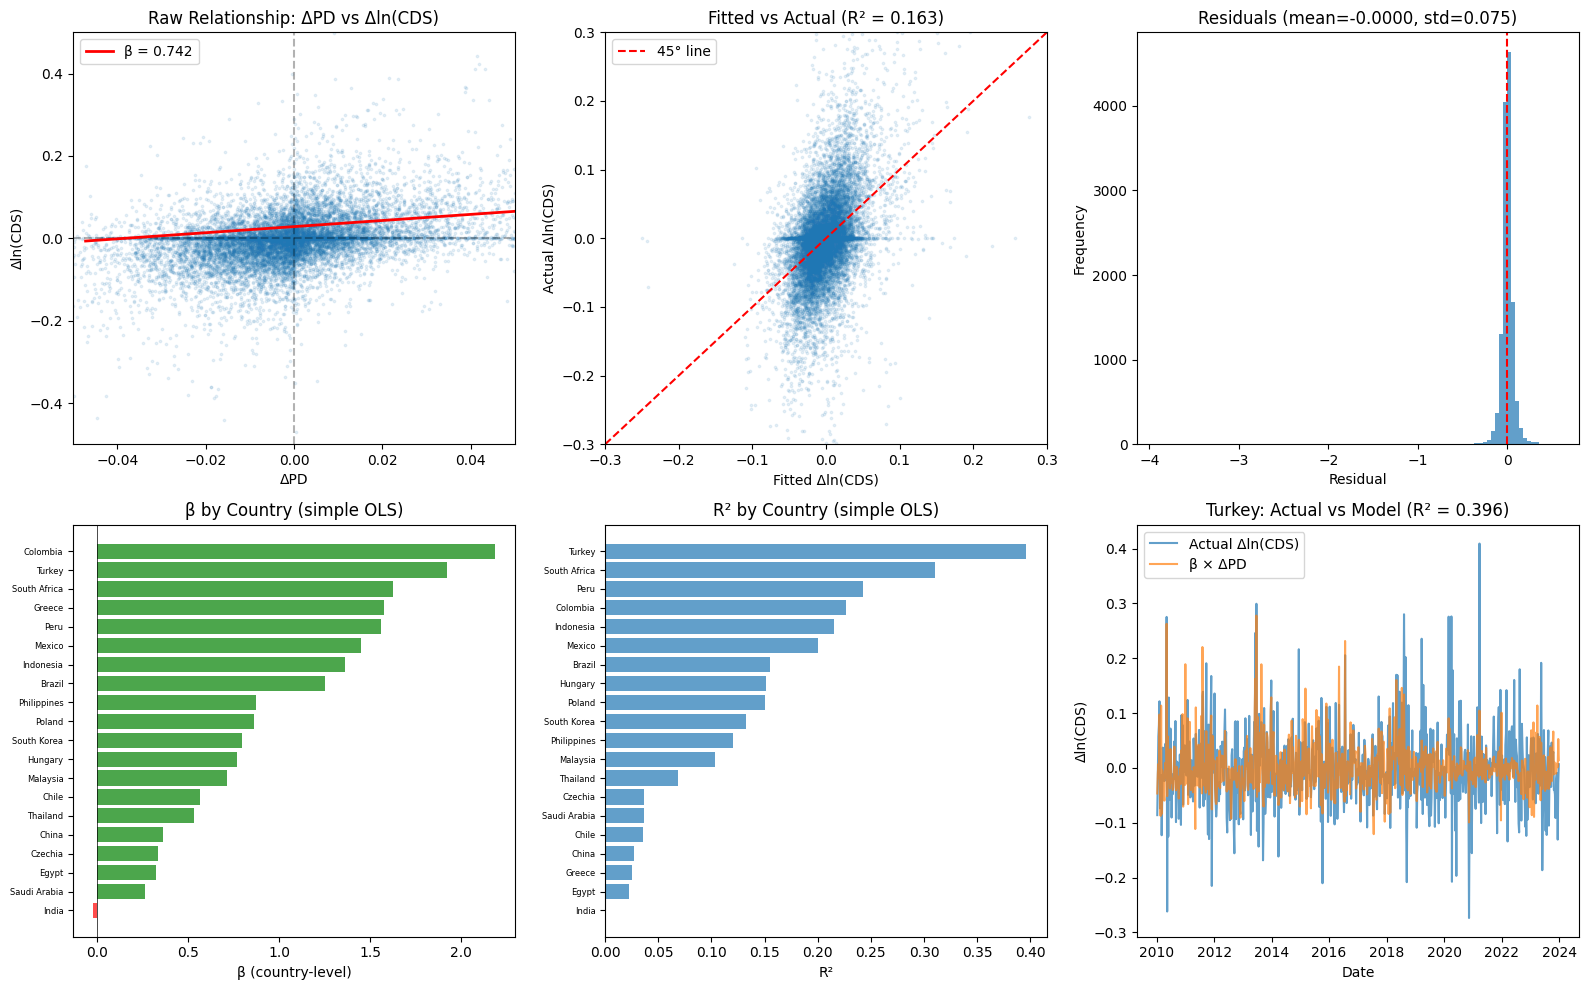


Summary by country:
     country      beta  r_squared   n
       India -0.022119   0.000484 457
Saudi Arabia  0.264769   0.036251 352
       Egypt  0.325609   0.022849 730
     Czechia  0.335837   0.036262 730
       China  0.360741   0.027014 378
    Thailand  0.533860   0.068078 730
       Chile  0.565185   0.035864 730
    Malaysia  0.715618   0.103202 378
     Hungary  0.768518   0.150902 730
 South Korea  0.794525   0.132504 730
      Poland  0.861893   0.150407 730
 Philippines  0.870840   0.119977 678
      Brazil  1.251430   0.155330 730
   Indonesia  1.362994   0.215218 730
      Mexico  1.451371   0.200109 730
        Peru  1.561973   0.242897 730
      Greece  1.576204   0.025371 730
South Africa  1.625624   0.310150 730
      Turkey  1.920592   0.395765 730
    Colombia  2.184411   0.227005 730

Countries with β > 0: 19 / 20
Mean β: 0.965
Mean R²: 0.133


In [352]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Scatter: ΔPD vs Δln(CDS) - raw relationship
ax = axes[0, 0]
ax.scatter(reg_data['d_pd'], reg_data['d_ln_cds'], alpha=0.1, s=3)
ax.axhline(0, color='k', linestyle='--', alpha=0.3)
ax.axvline(0, color='k', linestyle='--', alpha=0.3)
# Add regression line
x_line = np.linspace(reg_data['d_pd'].quantile(0.01), reg_data['d_pd'].quantile(0.99), 100)
y_line = model.params['Intercept'] + model.params['d_pd'] * x_line
ax.plot(x_line, y_line, 'r-', linewidth=2, label=f'β = {model.params["d_pd"]:.3f}')
ax.set_xlabel('ΔPD')
ax.set_ylabel('Δln(CDS)')
ax.set_title('Raw Relationship: ΔPD vs Δln(CDS)')
ax.set_xlim(-0.05, 0.05)
ax.set_ylim(-0.5, 0.5)
ax.legend()

# 2. Fitted vs Actual
ax = axes[0, 1]
reg_data['fitted'] = model.fittedvalues
ax.scatter(reg_data['fitted'], reg_data['d_ln_cds'], alpha=0.1, s=3)
max_val = 0.3
ax.plot([-max_val, max_val], [-max_val, max_val], 'r--', label='45° line')
ax.set_xlabel('Fitted Δln(CDS)')
ax.set_ylabel('Actual Δln(CDS)')
ax.set_title(f'Fitted vs Actual (R² = {model.rsquared:.3f})')
ax.set_xlim(-max_val, max_val)
ax.set_ylim(-max_val, max_val)
ax.legend()

# 3. Residuals distribution
ax = axes[0, 2]
residuals = model.resid
ax.hist(residuals, bins=100, edgecolor='none', alpha=0.7)
ax.axvline(0, color='r', linestyle='--')
ax.set_xlabel('Residual')
ax.set_ylabel('Frequency')
ax.set_title(f'Residuals (mean={residuals.mean():.4f}, std={residuals.std():.3f})')

# 4. Beta by country (run individual regressions)
from scipy.stats import linregress

betas = []
for country in reg_data['country'].unique():
    df = reg_data[reg_data['country'] == country]
    if len(df) > 50:
        slope, intercept, r, p, se = linregress(df['d_pd'].fillna(0), df['d_ln_cds'].fillna(0))
        betas.append({'country': country, 'beta': slope, 'r_squared': r**2, 'n': len(df)})

betas_df = pd.DataFrame(betas).sort_values('beta', ascending=True)

ax = axes[1, 0]
colors = ['green' if b > 0 else 'red' for b in betas_df['beta']]
ax.barh(range(len(betas_df)), betas_df['beta'], color=colors, alpha=0.7)
ax.set_yticks(range(len(betas_df)))
ax.set_yticklabels(betas_df['country'], fontsize=6)
ax.axvline(0, color='k', linestyle='-', linewidth=0.5)
ax.set_xlabel('β (country-level)')
ax.set_title('β by Country (simple OLS)')

# 5. R² by country
ax = axes[1, 1]
betas_df_sorted = betas_df.sort_values('r_squared', ascending=True)
ax.barh(range(len(betas_df_sorted)), betas_df_sorted['r_squared'], alpha=0.7)
ax.set_yticks(range(len(betas_df_sorted)))
ax.set_yticklabels(betas_df_sorted['country'], fontsize=6)
ax.set_xlabel('R²')
ax.set_title('R² by Country (simple OLS)')

# 6. Time series for top R² country
ax = axes[1, 2]
top_country = betas_df_sorted.iloc[-1]['country']
sample = reg_data[reg_data['country'] == top_country].copy().sort_values('date')
ax.plot(sample['date'], sample['d_ln_cds'], label='Actual Δln(CDS)', alpha=0.7)
ax.plot(sample['date'], sample['d_pd'] * betas_df_sorted.iloc[-1]['beta'], label='β × ΔPD', alpha=0.7)
ax.set_xlabel('Date')
ax.set_ylabel('Δln(CDS)')
ax.set_title(f'{top_country}: Actual vs Model (R² = {betas_df_sorted.iloc[-1]["r_squared"]:.3f})')
ax.legend()

plt.tight_layout()
plt.show()

# Print summary
print("\nSummary by country:")
print(betas_df[['country', 'beta', 'r_squared', 'n']].to_string(index=False))
print(f"\nCountries with β > 0: {(betas_df['beta'] > 0).sum()} / {len(betas_df)}")
print(f"Mean β: {betas_df['beta'].mean():.3f}")
print(f"Mean R²: {betas_df['r_squared'].mean():.3f}")

In [353]:
# Summary stats
print(f"\nMean R²: {results_df['r_squared'].mean():.3f}")
print(f"Median R²: {results_df['r_squared'].median():.3f}")
print(f"Mean β: {results_df['beta'].mean():.3f} (expect negative)")


Mean R²: 0.157
Median R²: 0.126
Mean β: -0.171 (expect negative)


## Validation of returns

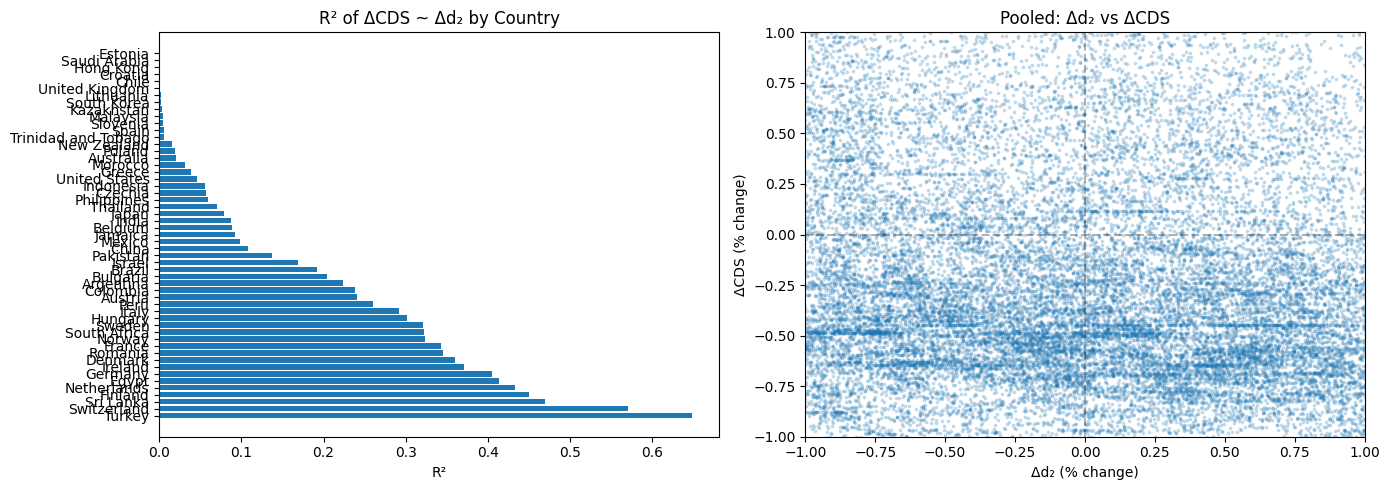

In [275]:
# ============================================================
# 8. Visualization
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² distribution
ax = axes[0]
ax.barh(results_df['country'], results_df['r_squared'])
ax.set_xlabel('R²')
ax.set_title('R² of ΔCDS ~ Δd₂ by Country')

# Scatter: Δd₂ vs ΔCDS (pooled)
ax = axes[1]
ax.scatter(panel['d2_z'], panel['cds_z'], alpha=0.2, s=3)
ax.axhline(0, color='k', linestyle='--', alpha=0.3)
ax.axvline(0, color='k', linestyle='--', alpha=0.3)
ax.set_xlabel('Δd₂ (% change)')
ax.set_ylabel('ΔCDS (% change)')
ax.set_title('Pooled: Δd₂ vs ΔCDS')
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)

plt.tight_layout()
plt.show()

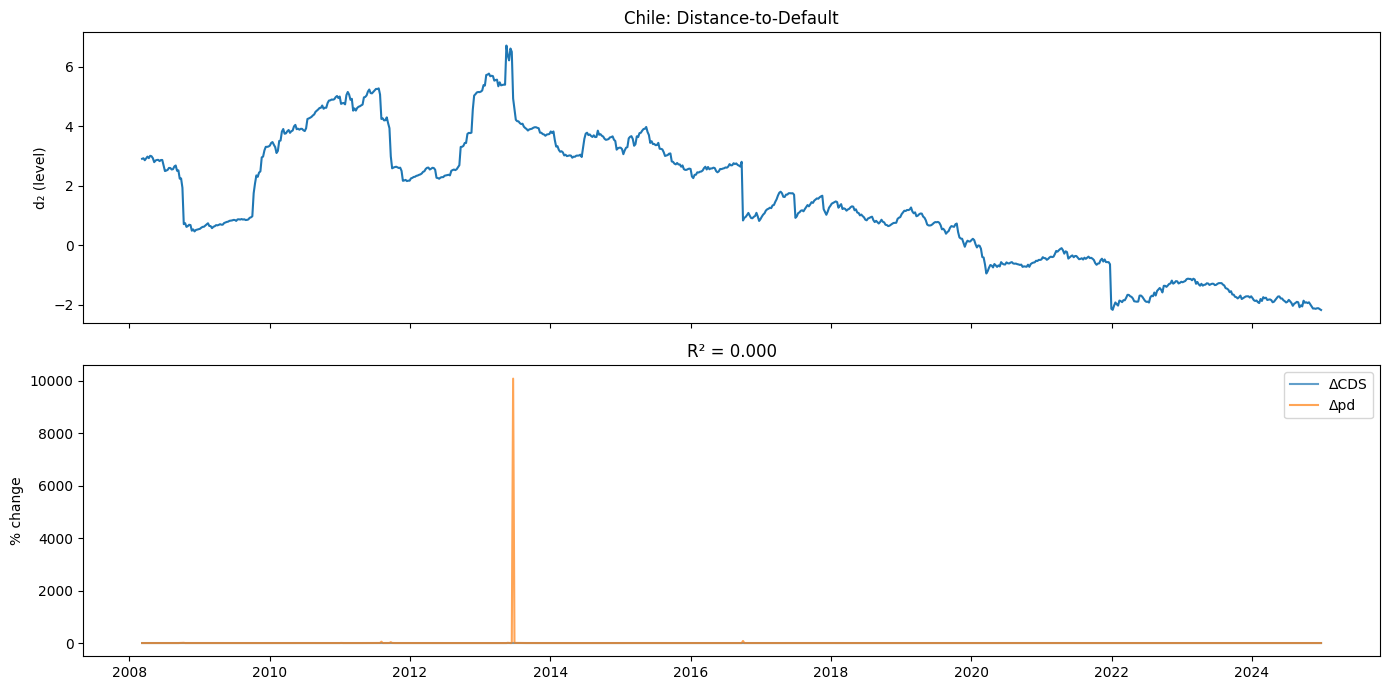

In [292]:
# Time series for sample country
sample_country = 'Chile'  # Highest R²
sample = panel[panel['country'] == sample_country].copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(sample['date'], sample['d2'])
axes[0].set_ylabel('d₂ (level)')
axes[0].set_title(f'{sample_country}: Distance-to-Default')

axes[1].plot(sample['date'], sample['d_cds'], label='ΔCDS', alpha=0.7)
axes[1].plot(sample['date'], sample['d_pd'], label='Δpd', alpha=0.7)
axes[1].set_ylabel('% change')
r_squared_val = results_df[results_df['country']==sample_country]['r_squared'].values[0]
axes[1].set_title(f'R² = {r_squared_val:.3f}')
axes[1].legend()

plt.tight_layout()
plt.show()

In [319]:
# Define groups (note: fixed "Tailand" typo)
oil_exporters = ['saudi arabia', 'united arab emirates', 'qatar', 'colombia', 
                 'mexico', 'brazil', 'egypt', 'malaysia']
controls = ['indonesia', 'philippines', 'turkey', 'chile', 'china', 
            'south africa', 'south korea', 'thailand']

# Tag countries
reg_data['group'] = reg_data['country'].str.lower().apply(
    lambda x: 'oil_exporter' if x in oil_exporters 
              else ('control' if x in controls else 'other')
)

print("Group counts:")
print(reg_data.groupby('group')['country'].nunique())
print("\nObs per group:")
print(reg_data.groupby('group').size())

# Split samples
oil_sample = reg_data[reg_data['group'] == 'oil_exporter']
control_sample = reg_data[reg_data['group'] == 'control']

# Run regressions
model_oil = smf.ols('d_ln_cds ~ d_pd + C(country) + C(ym)', data=oil_sample).fit()
model_control = smf.ols('d_ln_cds ~ d_pd + C(country) + C(ym)', data=control_sample).fit()

print("\n" + "="*50)
print("OIL EXPORTERS")
print("="*50)
print(f"Countries: {sorted(oil_sample['country'].unique())}")
print(f"β (ΔPD): {model_oil.params['d_pd']:.4f}")
print(f"t-stat: {model_oil.tvalues['d_pd']:.2f}")
print(f"R²: {model_oil.rsquared:.3f}")
print(f"N: {len(oil_sample)}")

print("\n" + "="*50)
print("CONTROLS (non-oil)")
print("="*50)
print(f"Countries: {sorted(control_sample['country'].unique())}")
print(f"β (ΔPD): {model_control.params['d_pd']:.4f}")
print(f"t-stat: {model_control.tvalues['d_pd']:.2f}")
print(f"R²: {model_control.rsquared:.3f}")
print(f"N: {len(control_sample)}")

print("\n" + "="*50)
print("COMPARISON")
print("="*50)
print(f"β difference: {model_oil.params['d_pd'] - model_control.params['d_pd']:.4f}")
print(f"R² difference: {model_oil.rsquared - model_control.rsquared:.3f}")

Group counts:
group
control         8
oil_exporter    6
other           6
Name: country, dtype: int64

Obs per group:
group
control         5436
oil_exporter    3650
other           4107
dtype: int64

OIL EXPORTERS
Countries: ['Brazil', 'Colombia', 'Egypt', 'Malaysia', 'Mexico', 'Saudi Arabia']
β (ΔPD): 0.6614
t-stat: 16.18
R²: 0.214
N: 3650

CONTROLS (non-oil)
Countries: ['Chile', 'China', 'Indonesia', 'Philippines', 'South Africa', 'South Korea', 'Thailand', 'Turkey']
β (ΔPD): 0.8227
t-stat: 25.20
R²: 0.249
N: 5436

COMPARISON
β difference: -0.1613
R² difference: -0.035


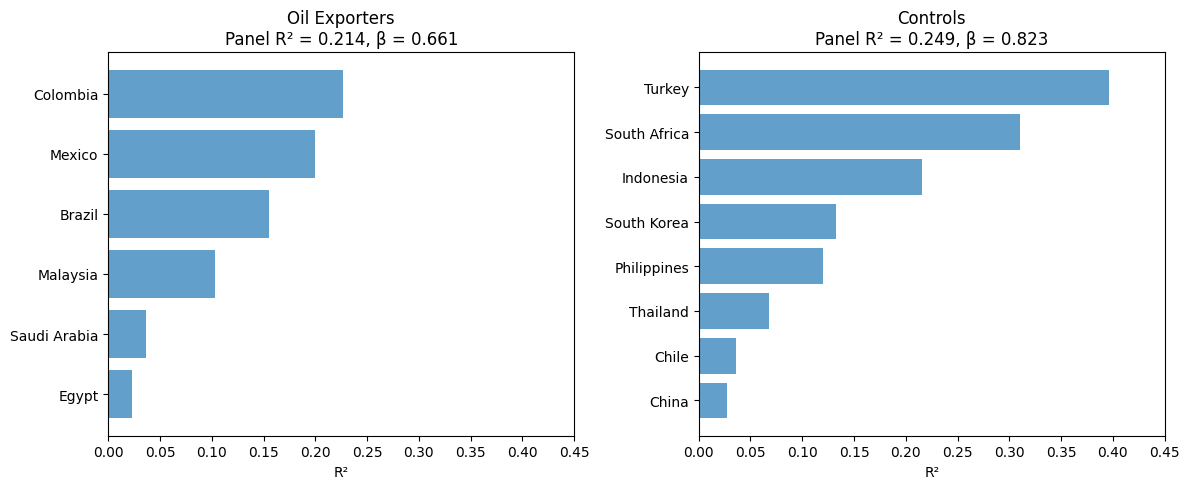

In [320]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# β by group and country
for i, (name, sample, model) in enumerate([
    ('Oil Exporters', oil_sample, model_oil), 
    ('Controls', control_sample, model_control)
]):
    betas = []
    for country in sample['country'].unique():
        df = sample[sample['country'] == country]
        if len(df) > 30:
            slope, _, r, _, _ = linregress(df['d_pd'].fillna(0), df['d_ln_cds'].fillna(0))
            betas.append({'country': country, 'beta': slope, 'r_squared': r**2})
    
    betas_df = pd.DataFrame(betas).sort_values('r_squared', ascending=True)
    
    ax = axes[i]
    ax.barh(betas_df['country'], betas_df['r_squared'], alpha=0.7)
    ax.set_xlabel('R²')
    ax.set_title(f'{name}\nPanel R² = {model.rsquared:.3f}, β = {model.params["d_pd"]:.3f}')
    ax.set_xlim(0, 0.45)

plt.tight_layout()
plt.show()

---
## 7. Export

In [321]:
panel.to_csv('data/processed/cca_baseline_results.csv', index=False)
print("Saved to data/processed/cca_baseline_results.csv")

Saved to data/processed/cca_baseline_results.csv
